In [3]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind
from natsort import natsorted
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import glob
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
from scipy.stats import linregress
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import nibabel as nib
import sys
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from nibabel import cifti2
from scipy.spatial import procrustes
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind, ttest_rel
np.random.seed(42)

In [4]:
blind_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_rh_Schaefer2YeoThalamus.npy')
blind_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_lh_Schaefer2YeoThalamus.npy')
control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_rh_Schaefer2YeoThalamus.npy')
control_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_lh_Schaefer2YeoThalamus.npy')
deaf_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deafsource_deaftarget_individual_fingerprint_fc_rh_Schaefer2YeoThalamus.npy')
deaf_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deafsource_deaftarget_individual_fingerprint_fc_lh_Schaefer2YeoThalamus.npy')
deaf_control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deaf_controlsource_deaf_controltarget_individual_fingerprint_fc_rh_Schaefer2YeoThalamus.npy')
deaf_control_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/deaf_controlsource_deaf_controltarget_individual_fingerprint_fc_lh_Schaefer2YeoThalamus.npy')

In [5]:
region_label = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 8,
       8, 8, 2, 8, 8, 8, 8, 8, 8, 8, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 8, 8, 8, 2, 8, 8, 2, 8, 8, 8, 8, 8, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 2,
       2, 8, 2, 8]

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Auditory']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

In [6]:
labels, ctab, names = nib.freesurfer.read_annot('../Dataset/template/rh.HCPMMP1.annot')
roi_names = [name.decode('utf-8') for name in names]
MMPname = roi_names[1:]

# Blind

In [7]:
nucleis = np.load('../Dataset/blind/yeo_thalamus_left_labels_Italy.npy')
nucleilabel = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']

In [8]:
wanglabel = pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t')
wanglabel = [x.split('- ')[1] for x in wanglabel.index.values]
len(wanglabel)

25

In [9]:
cb = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_blind_subjects', header=None)[0].values
sc = pd.read_csv('../Dataset/fingerprint_FC_dataset/Italy_control_subjects', header=None)[0].values

In [10]:
blind_V1 = []
blind_A1 = []
for i in np.arange(blind_MMP_lh.shape[0]):
    corr_matrix = blind_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    V1_cols = [idx for idx, label in enumerate(region_label[200:]) if label==1]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    blind_V1.append(avg_visual)

In [11]:
control_V1 = []
for i in np.arange(control_MMP_lh.shape[0]):
    corr_matrix = control_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    control_V1.append(avg_visual)

In [12]:
df_V1 = pd.concat([pd.DataFrame(blind_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1.columns = nucleis
df_V1['group'] = list(np.repeat('blind', len(blind_V1))) +  list(np.repeat('control', len(control_V1)))

In [13]:
features = df_V1.iloc[:, :-1]
group = df_V1['group']
df_V1_network = features.T.groupby(features.columns).mean().T
#df_V1_network = df_V1_network.div(features.mean(axis=1), axis=0)
df_V1_network.columns = nucleilabel 
#df_V1_network['subject'] = list(cb) + list(sc)
df_V1_network['group'] = group
#df_V1_network = df_V1_network[df_V1_network.LGN>-120]
#df_V1_network = df_V1_network[df_V1_network.LGN<10]

Visual -0.05694370454901897 0.9549441253012524
SomMot -3.3113741465434927 0.0023086161058569117
DorsAttn -0.4081014668494818 0.6859170490601703
SalVentAttn 1.6106341190372029 0.11708114694828087
Limbic 1.1631965523234737 0.25335053448851064
Cont 2.5399088355528923 0.016143450586758826
Default 2.6725918794304424 0.011744186264914533
FDR-corrected p-values: [0.95494413 0.01616031 0.80023656 0.20489201 0.35469075 0.03766805
 0.03766805]


/tmp/ipykernel_1608316/1257303581.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(network_order, rotation=30)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


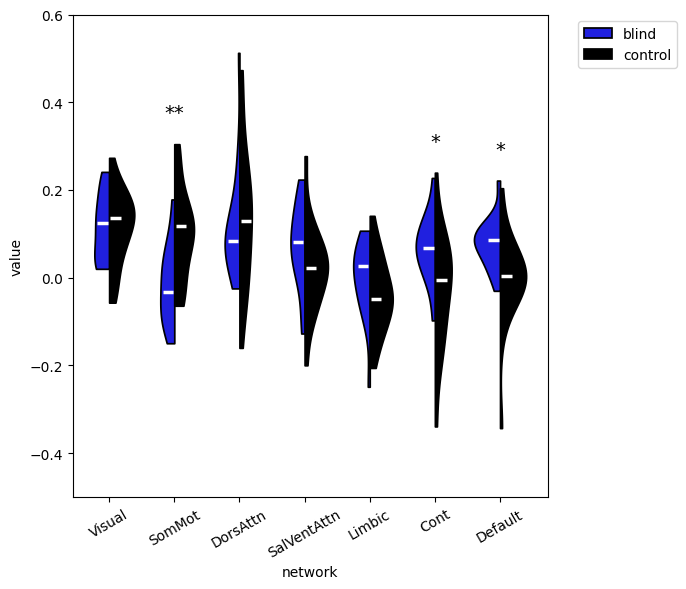

In [14]:
for region in [df_V1_network]:

    # -------------------------
    # Long format
    # -------------------------
    df_long = region.melt(
        id_vars=['group'],
        var_name='network',
        value_name='value'
    )

    network_order = df_long['network'].unique()

    plt.figure(figsize=(7, 6))

    ax = sns.violinplot(
        x='network',
        y='value',
        hue='group',
        data=df_long,
        order=network_order,
        split=True,
        inner=None,
        cut=0,
        palette=['blue', 'black']
    )
    # -------------------------
    # Median lines
    # -------------------------
    medians = (
        df_long.groupby(['network', 'group'])['value']
        .median()
        .reset_index()
    )

    offset = 0.18

    # -------------------------
    # Statistics
    # -------------------------
    pvals = []
    for i, net in enumerate(network_order):

        blind = df_long[
            (df_long['group'] == 'blind') &
            (df_long['network'] == net)
        ]['value']

        control = df_long[
            (df_long['group'] == 'control') &
            (df_long['network'] == net)
        ]['value']

        t, p = ttest_ind(blind, control, nan_policy='omit')
        pvals.append(p)

        print(net, t, p)

        # Significance stars (uncorrected)
        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = ''

        y_max = df_long.loc[
            df_long['network'] == net,
            'value'
        ].max()

        ax.text(
            i,
            y_max + 0.05,
            star,
            ha='center',
            va='bottom',
            fontsize=14
        )

        # Median bars on each half violin
        for group, sign in zip(['blind', 'control'], [-1, 1]):

            val = medians.loc[
                (medians['network'] == net) &
                (medians['group'] == group),
                'value'
            ].values

            if len(val) == 0:
                continue

            ax.hlines(
                y=val[0],
                xmin=i + sign * 0.02,
                xmax=i + sign * offset,
                color='white',
                linewidth=2.5,
                zorder=10
            )
    _, p_fdr, _, _ = multipletests(pvals, method='fdr_bh')
    print('FDR-corrected p-values:', p_fdr)
    # -------------------------
    # Formatting
    # -------------------------
    ax.set_ylim([-0.5, 0.6])
    ax.set_xticklabels(network_order, rotation=30)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        labels[:2],
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.savefig('thalamus_blind_yeo_violin_sommot.eps')
    plt.show()

# Deaf

In [15]:
nucleis = np.load('../Dataset/deaf/yeo_thalamus_right_labels_Deaf.npy')
nucleilabel = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']

In [16]:
deaf = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_subjects', header=None)[0].values
deaf_control = pd.read_csv('../Dataset/fingerprint_FC_dataset/Deaf_deaf_control_subjects', header=None)[0].values
subj = list(deaf) + list(deaf_control)

In [17]:
A1_cols = [idx for idx, label in enumerate(region_label[200:]) if 8==label]

In [18]:
deaf_A1 = []
for i in np.arange(deaf_MMP_rh.shape[0]):
    corr_matrix = deaf_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_auditory = auditory_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    deaf_A1.append(avg_auditory)

In [19]:
control_A1 = []
for i in np.arange(deaf_control_MMP_rh.shape[0]):
    corr_matrix = deaf_control_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    auditory_df = corr_df.iloc[:, A1_cols]
    avg_auditory = auditory_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    control_A1.append(avg_auditory)

In [20]:
df_A1 = pd.concat([pd.DataFrame(deaf_A1), pd.DataFrame(control_A1)]).reset_index(drop=True)
df_A1.columns = nucleis
#df_A1['subject'] = list(cb) + list(sc)
df_A1['group'] = list(np.repeat('deaf', len(deaf_A1))) +  list(np.repeat('control', len(control_A1)))

In [21]:
features = df_A1.iloc[:, :-1]
group = df_A1['group']
df_A1_network = features.T.groupby(features.columns).mean().T
#df_A1_network = df_A1_network.div(features.mean(axis=1), axis=0)
df_A1_network.columns = nucleilabel 
#df_A1_network['subject'] = list(cb) + list(sc)
df_A1_network['group'] = group
#df_V1_network = df_V1_network[df_V1_network.LGN>-120]
#df_V1_network = df_V1_network[df_V1_network.LGN<10]

/tmp/ipykernel_1608316/1419591770.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(network_order, rotation=30)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Visual 2.101741192930077 0.04034555102005361
SomMot 0.7823573890678704 0.43748613974972506
DorsAttn 0.7442106936107615 0.4600360048395403
SalVentAttn 1.4263528785593074 0.15963076710643903
Limbic 0.2746567318319158 0.7846477760756915
Cont 1.011542518341198 0.3163527034370852
Default 0.49018370695958213 0.626027062464397
FDR-corrected p-values: [0.28241886 0.64405041 0.64405041 0.55870768 0.78464778 0.64405041
 0.73036491]


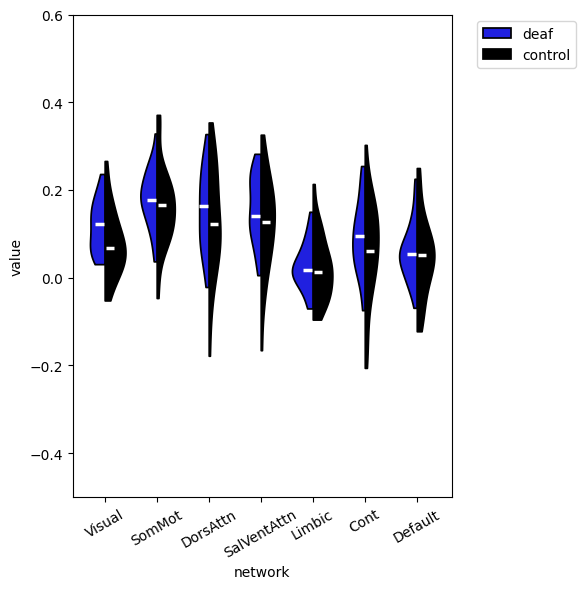

In [22]:
for region in [df_A1_network]:

    # -------------------------
    # Long format
    # -------------------------
    df_long = region.melt(
        id_vars=['group'],
        var_name='network',
        value_name='value'
    )

    network_order = df_long['network'].unique()

    plt.figure(figsize=(6, 6))

    ax = sns.violinplot(
        x='network',
        y='value',
        hue='group',
        data=df_long,
        order=network_order,
        split=True,
        inner=None,
        cut=0,
        palette=['blue', 'black']
    )

    # -------------------------
    # Median lines
    # -------------------------
    medians = (
        df_long.groupby(['network', 'group'])['value']
        .median()
        .reset_index()
    )

    offset = 0.18

    # -------------------------
    # Statistics
    # -------------------------
    pvals = []

    for net in network_order:

        deaf = df_long[
            (df_long['group'] == 'deaf') &
            (df_long['network'] == net)
        ]['value']

        control = df_long[
            (df_long['group'] == 'control') &
            (df_long['network'] == net)
        ]['value']

        t, p = ttest_ind(deaf, control, nan_policy='omit')

        print(net, t, p)
        pvals.append(p)

    # FDR correction
    _, p_fdr, _, _ = multipletests(pvals, method='fdr_bh')
    print('FDR-corrected p-values:', p_fdr)

    # -------------------------
    # Add median lines + FDR stars
    # -------------------------
    for i, net in enumerate(network_order):

        p = p_fdr[i]

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = ''

        y_max = df_long.loc[
            df_long['network'] == net,
            'value'
        ].max()

        ax.text(
            i,
            y_max + 0.05,
            star,
            ha='center',
            va='bottom',
            fontsize=14
        )

        # Median bars on each half violin
        for group, sign in zip(['deaf', 'control'], [-1, 1]):

            val = medians.loc[
                (medians['network'] == net) &
                (medians['group'] == group),
                'value'
            ].values

            if len(val) == 0:
                continue

            ax.hlines(
                y=val[0],
                xmin=i + sign * 0.02,
                xmax=i + sign * offset,
                color='white',
                linewidth=2.5,
                zorder=10
            )

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_ylim([-0.5, 0.6])
    ax.set_xticklabels(network_order, rotation=30)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        labels[:2],
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.savefig('thalamus_deaf_violin_cont.eps')
    plt.show()